In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("/content/sample_data/cleaned_data.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [3]:
print(df.shape)

df.info()

(392692, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 24.0+ MB


In [4]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


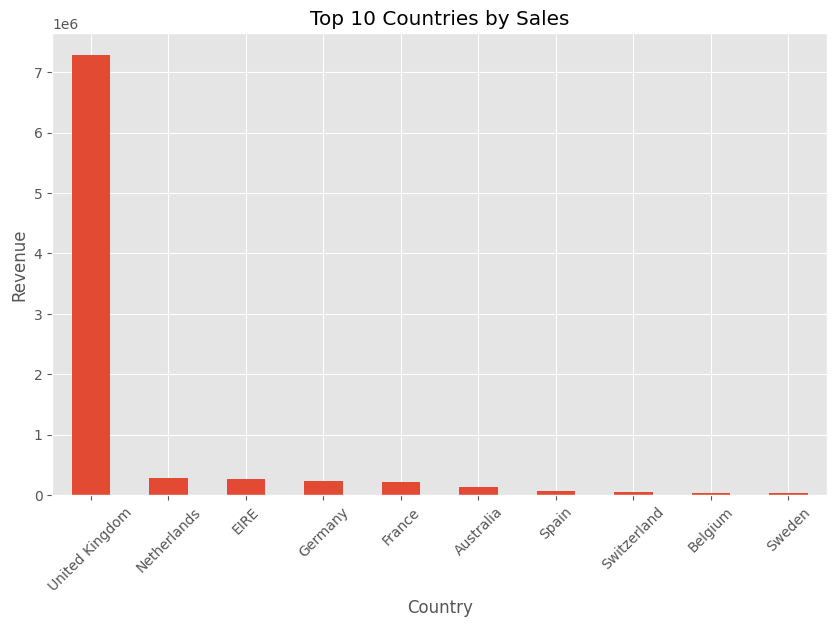

In [5]:
country_sales = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Sales")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

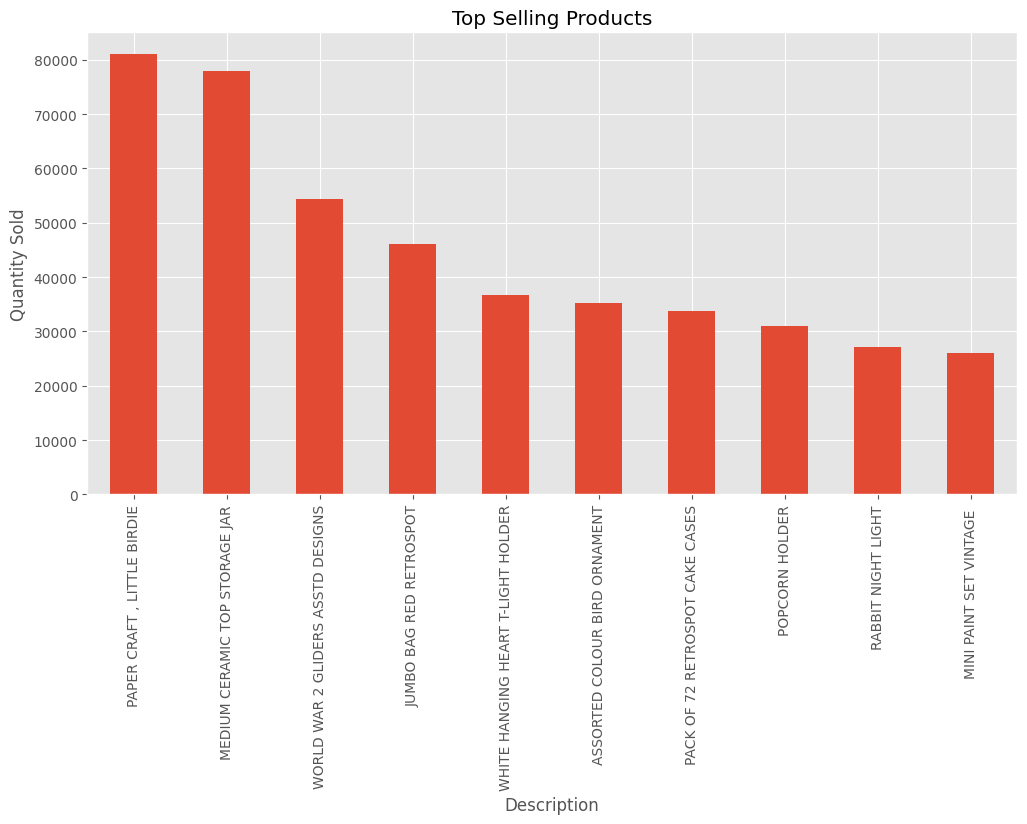

In [6]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top Selling Products")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.show()

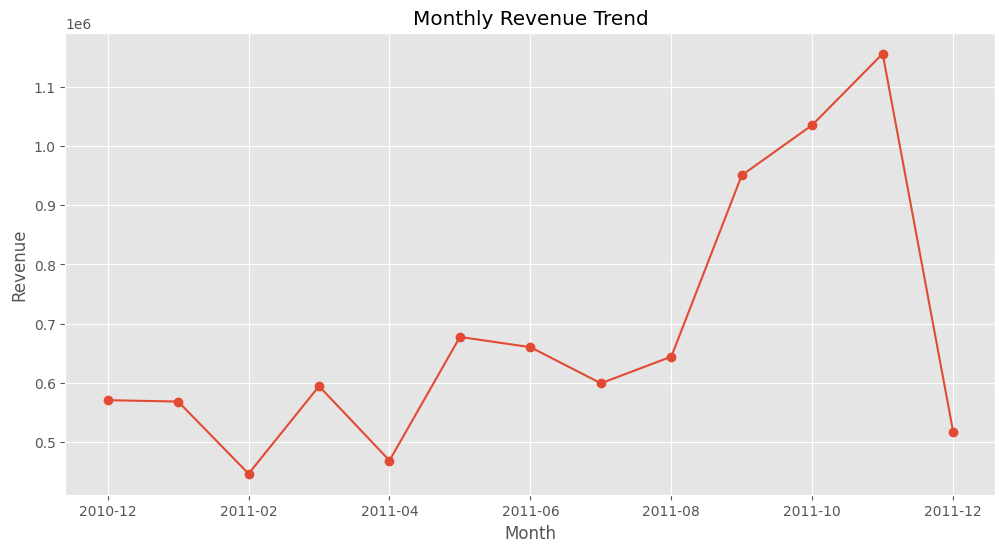

In [8]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

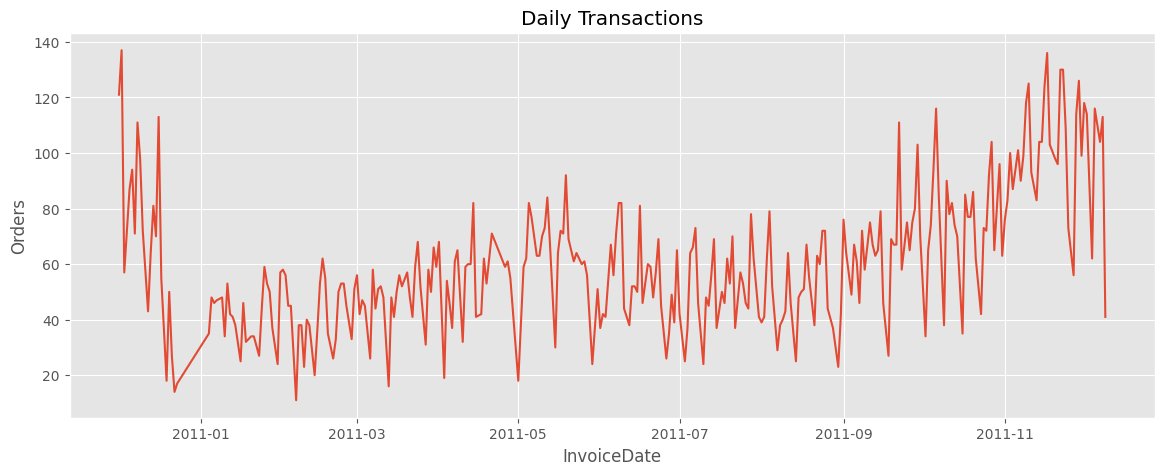

In [9]:
daily_orders = df.groupby(df["InvoiceDate"].dt.date)["InvoiceNo"].nunique()

plt.figure(figsize=(14,5))

daily_orders.plot()

plt.title("Daily Transactions")

plt.ylabel("Orders")

plt.show()

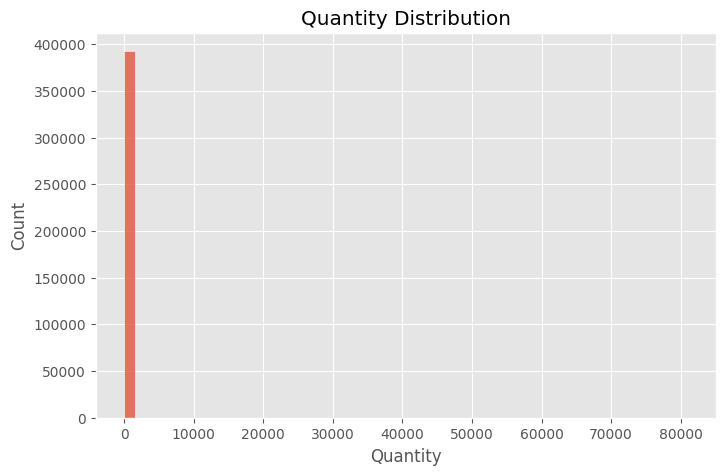

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Quantity"], bins=50)

plt.title("Quantity Distribution")

plt.show()

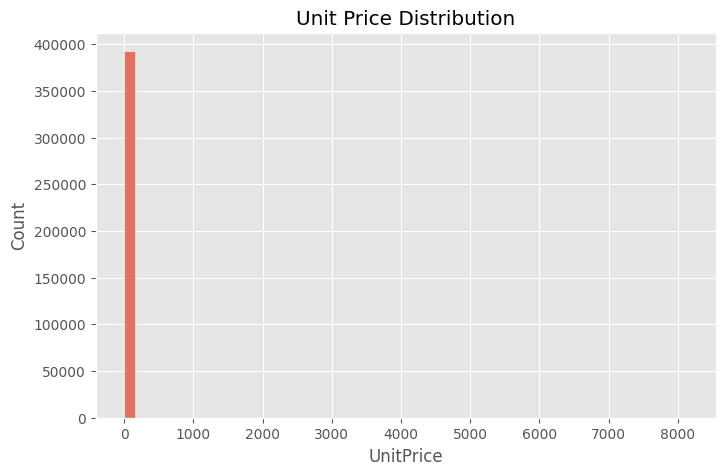

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["UnitPrice"], bins=50)

plt.title("Unit Price Distribution")

plt.show()

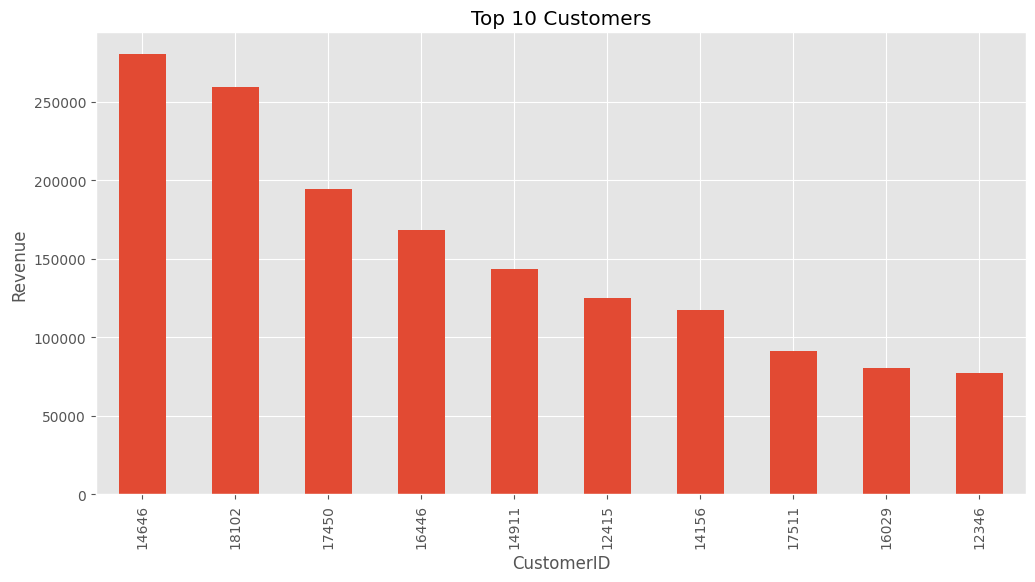

In [12]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")

plt.ylabel("Revenue")

plt.show()

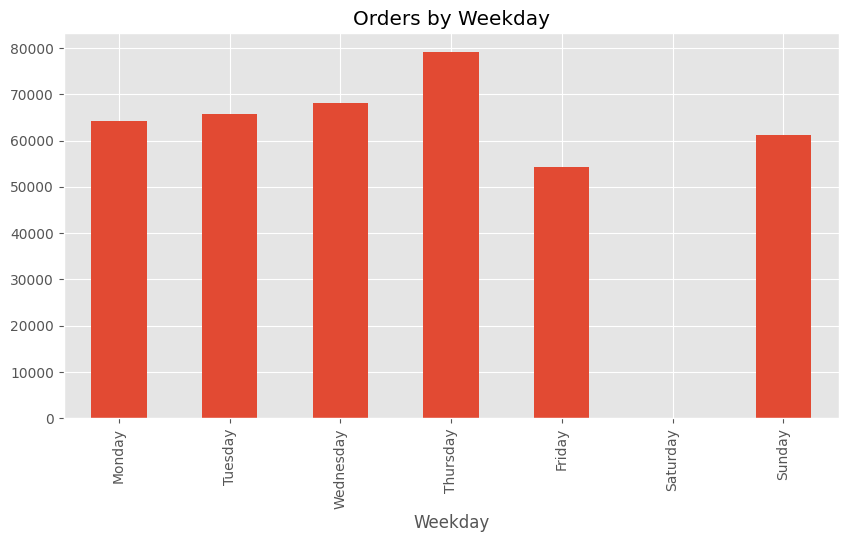

In [13]:
df["Weekday"] = df["InvoiceDate"].dt.day_name()

weekday_orders = df["Weekday"].value_counts()

weekday_orders = weekday_orders.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(10,5))

weekday_orders.plot(kind="bar")

plt.title("Orders by Weekday")

plt.show()

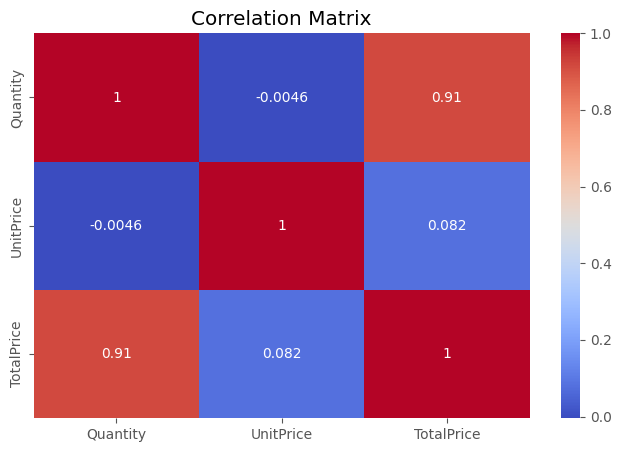

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Quantity","UnitPrice","TotalPrice"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

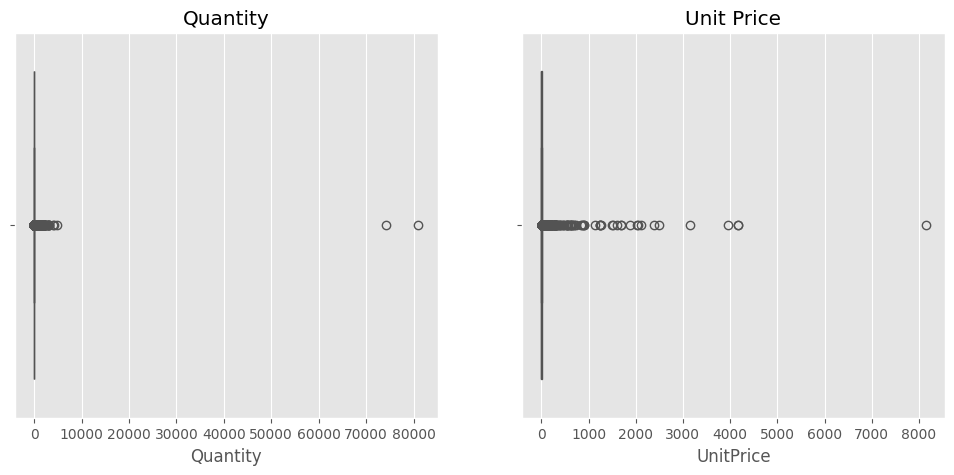

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.boxplot(x=df["Quantity"])

plt.title("Quantity")

plt.subplot(1,2,2)

sns.boxplot(x=df["UnitPrice"])

plt.title("Unit Price")

plt.show()

In [16]:
df.to_csv("/content/sample_data/eda_ready_data.csv",index=False)

print("EDA Dataset Saved Successfully")

EDA Dataset Saved Successfully


# Based on the analysis :

### Sales:
 The United Kingdom is the primary revenue generator, with significant revenue variations across different countries.
### Products:
 A small number of products account for a large proportion of total sales, indicating a skewed product demand.
### Customers:
 There's an uneven distribution in customer spending, with some customers contributing significantly more revenue than others.
### Revenue Trend:
 Monthly revenue exhibits seasonal patterns, with certain months experiencing noticeable sales peaks.
### Data Distribution:
 Both 'Quantity' and 'UnitPrice' columns are right-skewed and contain outliers.